# 2. Baseline TimeGAN: training, reconstruction, and completions

**Question:** can the four-network recurrent baseline reconstruct real books and generate
plausible sequences? This is the original **price-level, accumulated-Wiener-path** model.
Chapter 3 changes the midpoint feature to returns, still generated by the TimeGAN decoder.

Run top to bottom. `LOAD_EXISTING = True` uses `runs/timegan/model.pt` and its loss history.
Set it to `False` for a short exploratory training run with the budgets below; that run is
kept in memory and does not overwrite the saved baseline. Small budgets check the procedure,
not generation quality.

Previous: [data and features](order_book_analysis.ipynb).
Next: [price dynamics experiments](lobster_timegan_return_dynamics.ipynb).


In [1]:
from pathlib import Path
import sys

project_dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'dataset.py').is_file())
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown
from dataset import LOBSTERLevel10Dataset, WindowDataset

torch.set_num_threads(1)

from torch.utils.data import DataLoader
from modules import TimeGAN
from predict import load_checkpoint
from train import TimeGANTrainer, TrainingConfig
from training_balance_experiment import complete, noise_paths

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOAD_EXISTING = True
run_dir = project_dir / 'runs' / 'timegan'
config = TrainingConfig(autoencoder_steps=200, transition_steps=200, joint_steps=500)
train_data = LOBSTERLevel10Dataset(True)
validation_data = LOBSTERLevel10Dataset(False)


In [2]:
if LOAD_EXISTING:
    model, checkpoint = load_checkpoint(run_dir / 'model.pt', device=device)
    config = TrainingConfig(**checkpoint['training_config'])
    if checkpoint.get('price_representation', 'level') != 'level' or config.noise_kind != 'wiener_paths':
        raise ValueError('This chapter expects the original price-level/Wiener-path baseline.')
    np.testing.assert_allclose(checkpoint['feature_mean'].cpu(), train_data.feature_mean)
    np.testing.assert_allclose(checkpoint['feature_std'].cpu(), train_data.feature_std)
    history = pd.read_csv(run_dir / 'losses.csv')
    print('Loaded the original saved baseline.')
else:
    model = TimeGAN().to(device)
    loader = DataLoader(WindowDataset(train_data.features, config.sequence_length),
                        batch_size=config.batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(0))
    history = pd.DataFrame(TimeGANTrainer(model, config).fit(loader))
    print('Finished an exploratory training run.')
print(config)


Loaded the original saved baseline.
TrainingConfig(sequence_length=64, batch_size=64, learning_rate=0.0003, gradient_clip=1.0, lam=1.0, eta=10.0, autoencoder_steps=1000, transition_steps=1000, joint_steps=5000, discriminator_learning_rate=None, generator_updates=1, context_loss_weight=0.0, context_horizon=16, price_representation='level', noise_kind='wiener_paths', price_moment_weight=0.0)


## Architecture and three training stages

The causal GRU embedder maps `(batch, events, 40)` to `(batch, events, 128)`.
The decoder reconstructs a book at every event. The generator's recurrent state is its
latent output; the discriminator scores latent sequences. The 128-dimensional latent
summarizes preceding events but is larger than the 40 features per event.

Training first fits reconstruction, then teaches the generator next-latent transitions
using real preceding latents, then jointly trains all four networks. Reconstruction
updates the embedder and decoder; it does not directly teach the generator decoded price
continuations. Joint training adds adversarial feedback and latent transition supervision.


TimeGAN(
  (embedder): Embedder(
    (recurrent): GRU(40, 128, batch_first=True)
  )
  (decoder): Decoder(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=40, bias=True)
  )
  (generator): Generator(
    (initial): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
    )
    (cell): GRUCell(128, 128)
  )
  (discriminator): Discriminator(
    (recurrent): GRU(128, 64, batch_first=True, bidirectional=True)
    (output): Linear(in_features=128, out_features=1, bias=True)
  )
)
Features (1, 64, 40) → latents (1, 64, 128) → reconstruction (1, 64, 40)


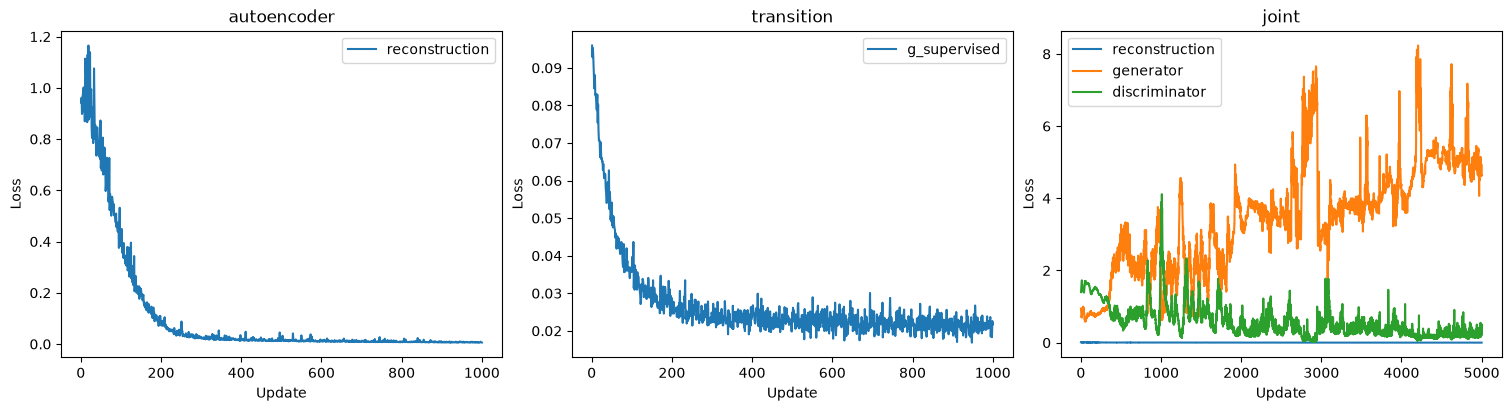

In [3]:
print(model)
with torch.inference_mode():
    x = train_data.features[:config.sequence_length][None].to(device)
    h = model.embedder(x)
    reconstructed = model.decoder(h)
print(f'Features {tuple(x.shape)} → latents {tuple(h.shape)} → reconstruction {tuple(reconstructed.shape)}')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for ax, stage, losses in zip(axes, ['autoencoder', 'transition', 'joint'],
                            [['reconstruction'], ['g_supervised'], ['reconstruction', 'generator', 'discriminator']]):
    rows = history.loc[history['stage'] == stage].set_index('step')
    rows[losses].plot(ax=ax, title=stage, xlabel='Update', ylabel='Loss')
plt.show()


## Can it recover observed books?

This replaces the standalone autoencoder experiment with a check of the actual baseline's
embedder and decoder. Nonoverlapping windows span each split; the two examples show one
64-event window per split. The midpoint has already been observed by the embedder, so this
is **reconstruction**, not forecasting. Positive signed errors indicate upward bias.
Price bands show quote ranges at levels 1, 5, and 10, not uncertainty.


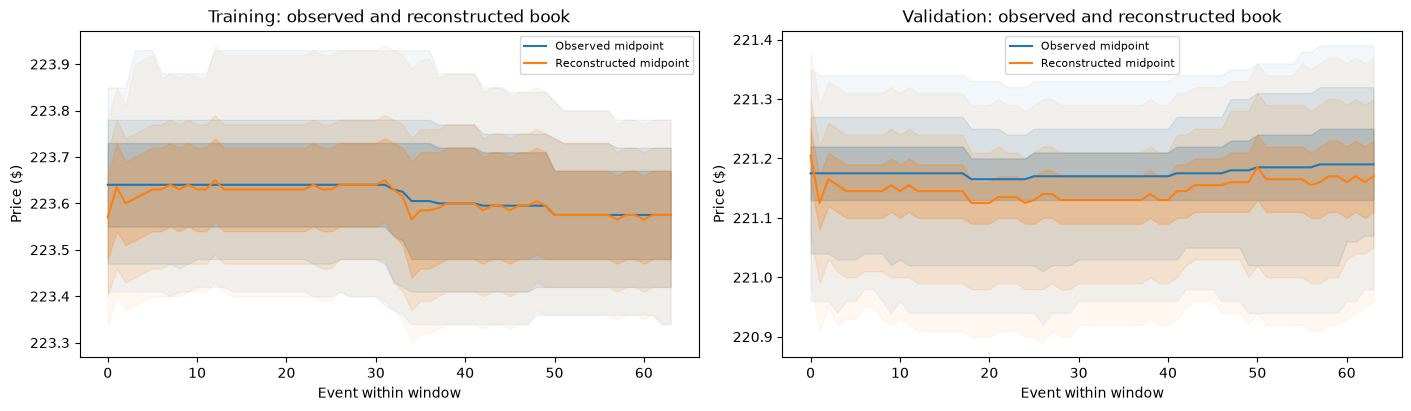

,Feature MSE,Midpoint MAE ($),Signed midpoint error ($),Spread MAE ($),Size MAE (shares)
Split,,,,,
Training,0.000874,0.016365,-0.013095,0.000206,3.379834
Validation,0.000517,0.017743,-0.011457,0.000008,3.855148


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
rows = []
model.eval()
with torch.inference_mode():
    for ax, (label, data) in zip(axes, [('Training', train_data), ('Validation', validation_data)]):
        windows = WindowDataset(data.features, config.sequence_length, stride=config.sequence_length)
        indices = np.linspace(0, len(windows) - 1, min(256, len(windows))).round().astype(int)
        inputs = torch.stack([windows[int(i)] for i in indices])
        predictions = torch.cat([model(batch.to(device)).cpu() for batch in inputs.split(64)])
        originals = [data.books.iloc[i * config.sequence_length:(i + 1) * config.sequence_length]
                     for i in indices]
        recovered = [data.feature_sequence_to_df(window) for window in predictions]
        real = np.stack([frame.to_numpy() for frame in originals])
        fake = np.stack([frame.to_numpy() for frame in recovered])
        midpoint_error = (fake[..., 0] + fake[..., 2] - real[..., 0] - real[..., 2]) / 20_000
        spread_error = (fake[..., 0] - fake[..., 2] - real[..., 0] + real[..., 2]) / 10_000
        rows.append({'Split': label, 'Feature MSE': (predictions - inputs).square().mean().item(),
                     'Midpoint MAE ($)': np.abs(midpoint_error).mean(),
                     'Signed midpoint error ($)': midpoint_error.mean(),
                     'Spread MAE ($)': np.abs(spread_error).mean(),
                     'Size MAE (shares)': np.abs(fake[..., 1::2] - real[..., 1::2]).mean()})
        sample = len(indices) // 2
        for frame, color, name in [(originals[sample], 'tab:blue', 'Observed'),
                                    (recovered[sample], 'tab:orange', 'Reconstructed')]:
            for level, alpha in [(10, 0.06), (5, 0.12), (1, 0.25)]:
                ax.fill_between(np.arange(len(frame)), frame[f'BIDp{level}'] / 10_000,
                                 frame[f'ASKp{level}'] / 10_000, color=color, alpha=alpha)
            ax.plot(np.arange(len(frame)), (frame['ASKp1'] + frame['BIDp1']) / 20_000,
                    color=color, label=f'{name} midpoint')
        ax.set(title=f'{label}: observed and reconstructed book', xlabel='Event within window', ylabel='Price ($)')
        ax.legend(fontsize=8)
plt.show()
display(pd.DataFrame(rows).set_index('Split').round(6))


## Noise and a whole-day completion overview

The original baseline feeds accumulated paths `W_t` to the generator: each channel starts
at zero and accumulates Gaussian increments with variance `1 / (T - 1)` for a training
window of length `T`. Its random initial latent uses a separate Gaussian vector.
The later return model instead receives increments, whose variance stays constant.

Three independent continuations start from the final real training context and then use
only generated history. The orange validation curve is a comparison, never a generation
input. These approximately 40,000-event rollouts extend far beyond the 64-event training
window; they illustrate failure modes and do not establish long-horizon forecast quality.


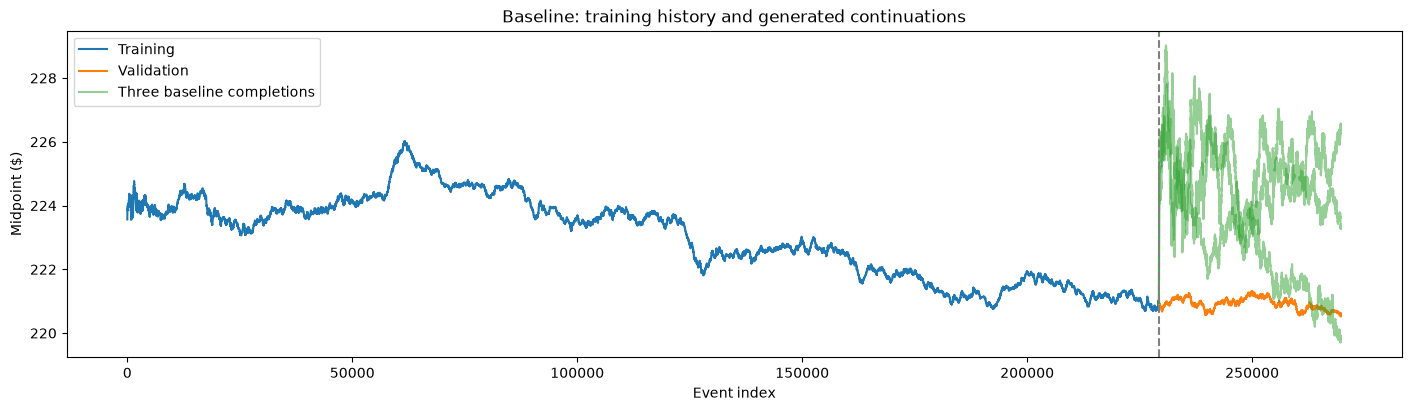

In [5]:
N_COMPLETIONS = 3
horizon = len(validation_data)
context = train_data.features[-config.sequence_length:][None].to(device)
paths = noise_paths(N_COMPLETIONS, horizon, model, config.sequence_length)
features = complete(model, context.repeat(N_COMPLETIONS, 1, 1), paths)
completions = [train_data.feature_sequence_to_df(window) for window in features]

def midpoint(book):
    return ((book['ASKp1'] + book['BIDp1']) / 20_000).to_numpy()

boundary = len(train_data)
fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
ax.plot(np.arange(boundary), midpoint(train_data.books), color='tab:blue', label='Training')
ax.plot(np.arange(boundary, boundary + horizon), midpoint(validation_data.books),
        color='tab:orange', label='Validation')
for i, book in enumerate(completions):
    ax.plot(np.arange(boundary - 1, boundary + horizon),
            np.r_[midpoint(train_data.books)[-1], midpoint(book)], color='tab:green', alpha=0.5,
            label='Three baseline completions' if i == 0 else None)
ax.axvline(boundary - 0.5, color='gray', linestyle='--')
ax.set(title='Baseline: training history and generated continuations', xlabel='Event index', ylabel='Midpoint ($)')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.legend()
plt.show()


## What this establishes

Reconstruction errors and generation errors measure different paths through the model.
Low reconstruction loss alone cannot establish realistic generated dynamics. The completion
chart motivates the next chapter's controlled tests of noise, training balance, conditional
supervision, and the price representation. We assess generation statistics in chapter 4.
